In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('house_prices.csv')
data.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
data.shape


(187531, 21)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [5]:
missing_sum=data.isnull().sum()
missing_sum=missing_sum[missing_sum>0]
missing_percentage=missing_sum/len(data)*100
missing_values =pd.DataFrame()
missing_values['missing_sum']=missing_sum
missing_values['missing_percentage']=missing_percentage
missing_values=missing_values.sort_values(by='missing_sum', ascending=False)
missing_values


,missing_sum,missing_percentage
Plot Area,187531,100.000000
Dimensions,187531,100.000000
Society,109678,58.485264
Super Area,107685,57.422506
Car Parking,103357,55.114621
overlooking,81436,43.425354
Carpet Area,80673,43.018488
facing,70233,37.451408
Ownership,65517,34.936624
Balcony,48935,26.094352


Data cleaning

In [6]:
data = data.drop(columns=['Dimensions', 'Plot Area','Society','Super Area','Car Parking'])

In [7]:
data['overlooking'] = data['overlooking'].fillna('Unknown')

In [8]:
data['Carpet Area'] 

0          500 sqft
1          473 sqft
2          779 sqft
3          530 sqft
4          635 sqft
            ...    
187526          NaN
187527          NaN
187528    1250 sqft
187529          NaN
187530          NaN
Name: Carpet Area, Length: 187531, dtype: object

In [9]:
def clean_area(x):
    if pd.isna(x):
        return np.nan
    x=str(x).lower()
    match = re.match(r'([0-9.]+)\s*(.*)',x)
    if match:
        value = float(match.group(1))
        unit = match.group(2).strip()
        if 'sqm' in unit or 'sq.m.' in unit:
            return value * 10.7639
        elif 'sqyrd' in unit:
            return value * 9.0
        return value
    return np.nan 

In [10]:
data['Carpet Area'] = data['Carpet Area'].apply(clean_area)
data['Carpet Area'] = data['Carpet Area'].fillna(data['Carpet Area'].median())

In [11]:
data['Carpet Area'].isnull().sum()

np.int64(0)

In [12]:
data['Carpet Area']

0          500.0
1          473.0
2          779.0
3          530.0
4          635.0
           ...  
187526    1064.0
187527    1064.0
187528    1250.0
187529    1064.0
187530    1064.0
Name: Carpet Area, Length: 187531, dtype: float64

In [13]:
data['facing'].value_counts()

facing
East            54741
North - East    24220
North           16533
West             8574
South            4694
North - West     3843
South - East     2622
South -West      2071
Name: count, dtype: int64

In [14]:
data['facing'] = data['facing'].fillna('Unknown')
data['facing'].value_counts()

facing
Unknown         70233
East            54741
North - East    24220
North           16533
West             8574
South            4694
North - West     3843
South - East     2622
South -West      2071
Name: count, dtype: int64

In [15]:
data['Ownership'].value_counts()

Ownership
Freehold                112229
Leasehold                 5285
Co-operative Society      3431
Power Of Attorney         1069
Name: count, dtype: int64

In [16]:
data['Ownership'] = data['Ownership'].fillna('Unknown')
data['Ownership'].value_counts()

Ownership
Freehold                112229
Unknown                  65517
Leasehold                 5285
Co-operative Society      3431
Power Of Attorney         1069
Name: count, dtype: int64

In [17]:
# Chuyển đổi "Amount(in rupees)" từ chuỗi sang số và quy đổi sang USD
def parse_amount(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    match = re.match(r'([0-9.]+)\s*(Lac|Cr)', x, re.IGNORECASE)
    if match:
        val = float(match.group(1))
        unit = match.group(2).lower()
        rupees = 0
        if unit == 'lac':
            rupees = val * 100000
        elif unit == 'cr':
            rupees = val * 10000000
        
        # Giả sử tỷ giá 1 USD ≈ 83 INR
        usd_value = rupees / 83.0
        return usd_value
    return np.nan

data['Price_total'] = data['Amount(in rupees)'].apply(parse_amount)

# Kiểm tra kết quả
print("Null trong Price_total:", data['Price_total'].isnull().sum())
print("\nMẫu dữ liệu (Quy đổi sang USD):")
print(data[['Amount(in rupees)', 'Price_total']].head(10))

Null trong Price_total: 9684

Mẫu dữ liệu (Quy đổi sang USD):
  Amount(in rupees)    Price_total
0           42 Lac    50602.409639
1           98 Lac   118072.289157
2          1.40 Cr   168674.698795
3           25 Lac    30120.481928
4          1.60 Cr   192771.084337
5           45 Lac    54216.867470
6         16.5 Lac    19879.518072
7           60 Lac    72289.156627
8           60 Lac    72289.156627
9          1.60 Cr   192771.084337


In [18]:
data.drop(columns='Amount(in rupees)',inplace=True)

In [19]:
data['Price_total']

0          50602.409639
1         118072.289157
2         168674.698795
3          30120.481928
4         192771.084337
              ...      
187526     75903.614458
187527     66265.060241
187528     91566.265060
187529     36144.578313
187530    142168.674699
Name: Price_total, Length: 187531, dtype: float64

In [20]:
# Tách cột Floor chỉ lấy floor_number
def parse_floor(x):
    if pd.isna(x):
        return np.nan
    match = re.match(r'(\d+)\s*out\s*of\s*(\d+)', str(x))
    if match:
        return int(match.group(1))
    return np.nan

data['floor_number'] = data['Floor'].apply(parse_floor)

# Chuyển Bathroom và Balcony sang số, "> 10" → 11
def parse_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if '>' in x:
        return 11
    try:
        return int(float(x))
    except ValueError:
        return np.nan

data['Bathroom'] = data['Bathroom'].apply(parse_count)
data['Balcony'] = data['Balcony'].apply(parse_count)

# Điền null bằng median
data['floor_number'] = data['floor_number'].fillna(data['floor_number'].median())
data['Bathroom'] = data['Bathroom'].fillna(data['Bathroom'].median())
data['Balcony'] = data['Balcony'].fillna(data['Balcony'].median())

print("Kiểm tra null còn lại:")
print(data[['floor_number', 'Bathroom', 'Balcony']].isnull().sum())

Kiểm tra null còn lại:
floor_number    0
Bathroom        0
Balcony         0
dtype: int64


In [21]:
# Điền null cho các cột phân loại còn lại
data['Status'] = data['Status'].fillna('Ready to Move')
data['Transaction'] = data['Transaction'].fillna(data['Transaction'].mode()[0])
data['Furnishing'] = data['Furnishing'].fillna(data['Furnishing'].mode()[0])

# Trích xuất số phòng (BHK) từ Title
def extract_bhk(title):
    if pd.isna(title):
        return np.nan
    match = re.search(r'(\d+)\s*BHK', str(title), re.IGNORECASE)
    if match:
        return int(match.group(1))
    return np.nan

data['BHK'] = data['Title'].apply(extract_bhk)
data['BHK'] = data['BHK'].fillna(data['BHK'].median())

# Xóa cột không cần thiết cho mô hình
data = data.drop(columns=['Index', 'Title', 'Description',
                           'Price (in rupees)', 'Floor'])

# Xóa dòng không có giá (target)
print(f"Số dòng trước khi xóa null target: {len(data)}")
data = data.dropna(subset=['Price_total'])
print(f"Số dòng sau khi xóa null target: {len(data)}")

# Kiểm tra tổng quan null
null_counts = data.isnull().sum()
print(f"\nTổng null còn lại: {null_counts.sum()}")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Không còn giá trị null nào!")

# Đảm bảo không còn null
assert data.isnull().sum().sum() == 0, "Vẫn còn giá trị null!"
print(f"\nShape cuối cùng: {data.shape}")
data.head()

Số dòng trước khi xóa null target: 187531
Số dòng sau khi xóa null target: 177847

Tổng null còn lại: 0
Không còn giá trị null nào!

Shape cuối cùng: (177847, 13)


,location,Carpet Area,Status,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership,Price_total,floor_number,BHK
0,thane,500.0,Ready to Move,Resale,Unfurnished,Unknown,Unknown,1.0,2.0,Unknown,50602.409639,10.0,1.0
1,thane,473.0,Ready to Move,Resale,Semi-Furnished,East,Garden/Park,2.0,2.0,Freehold,118072.289157,3.0,2.0
2,thane,779.0,Ready to Move,Resale,Unfurnished,East,Garden/Park,2.0,2.0,Freehold,168674.698795,10.0,2.0
3,thane,530.0,Ready to Move,Resale,Unfurnished,Unknown,Unknown,1.0,1.0,Unknown,30120.481928,1.0,1.0
4,thane,635.0,Ready to Move,Resale,Unfurnished,West,"Garden/Park, Main Road",2.0,2.0,Co-operative Society,192771.084337,20.0,2.0


## Phân tích khám phá dữ liệu (EDA)

### Phân phối các biến phân loại (Categorical Variables)

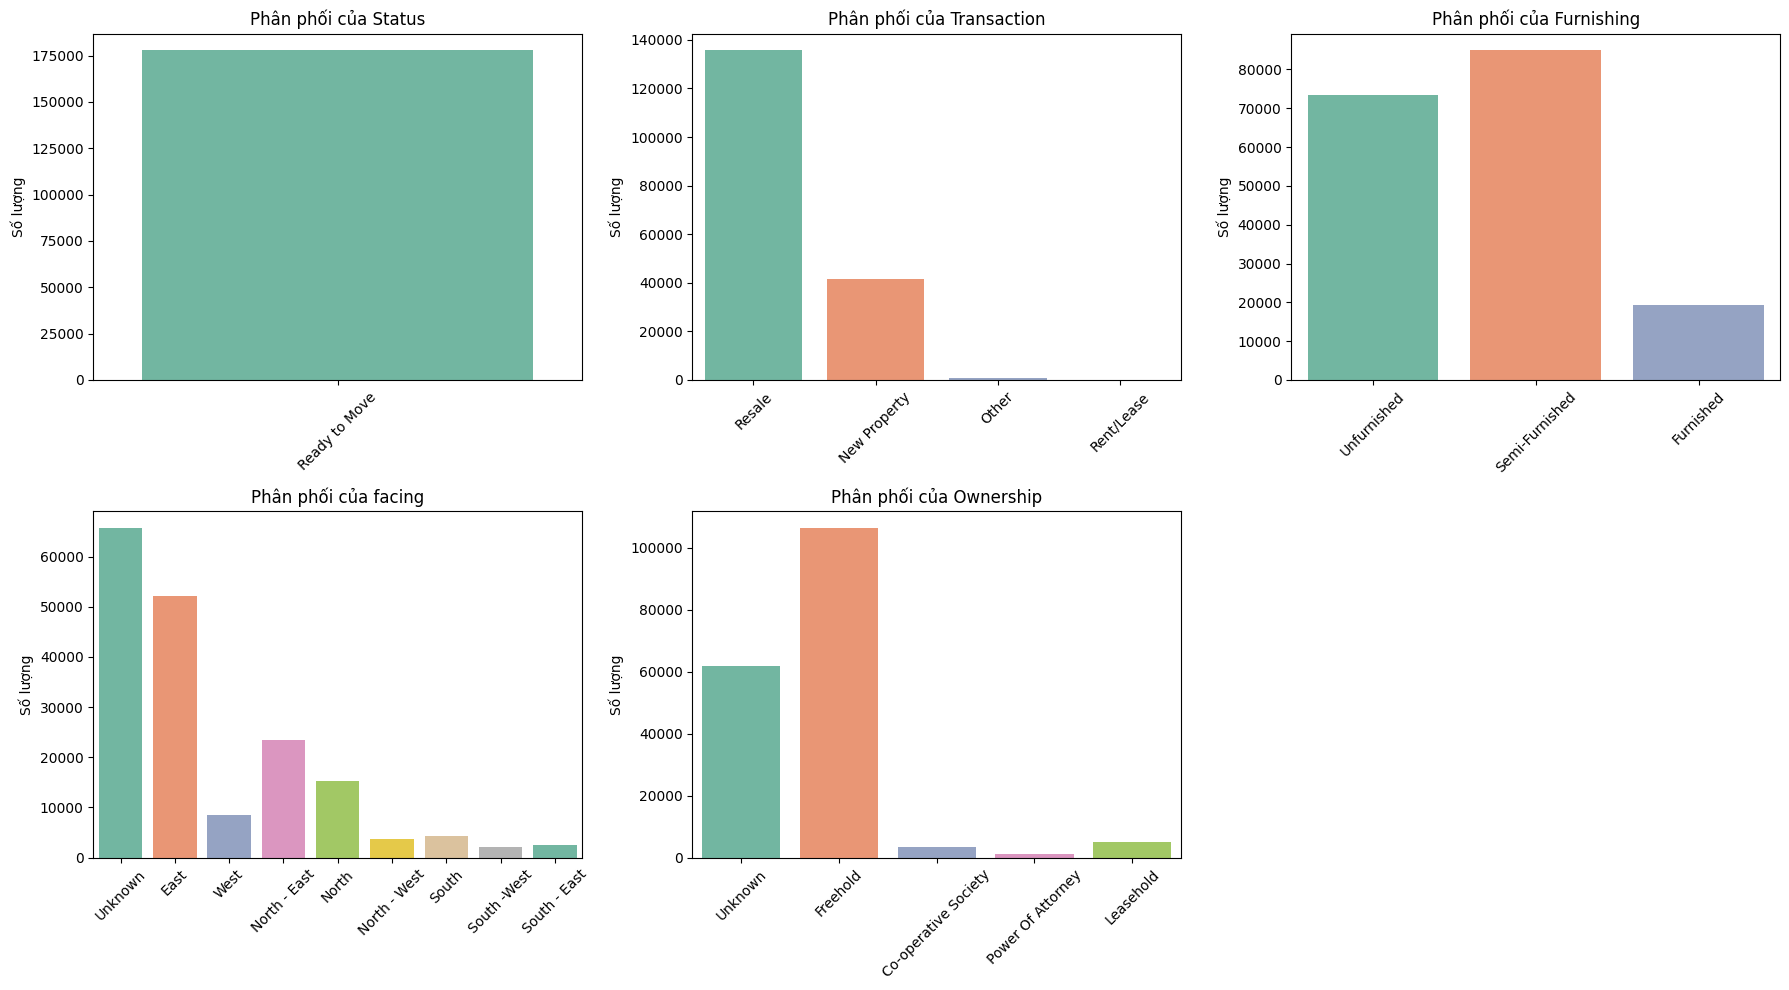

In [22]:
cat_cols = ['Status', 'Transaction', 'Furnishing', 'facing', 'Ownership']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in data.columns:
        sns.countplot(data=data, x=col, ax=axes[i], palette='Set2')
        axes[i].set_title(f'Phân phối của {col}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel('Số lượng')
        axes[i].set_xlabel('')

# Xóa trục trống nếu có
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

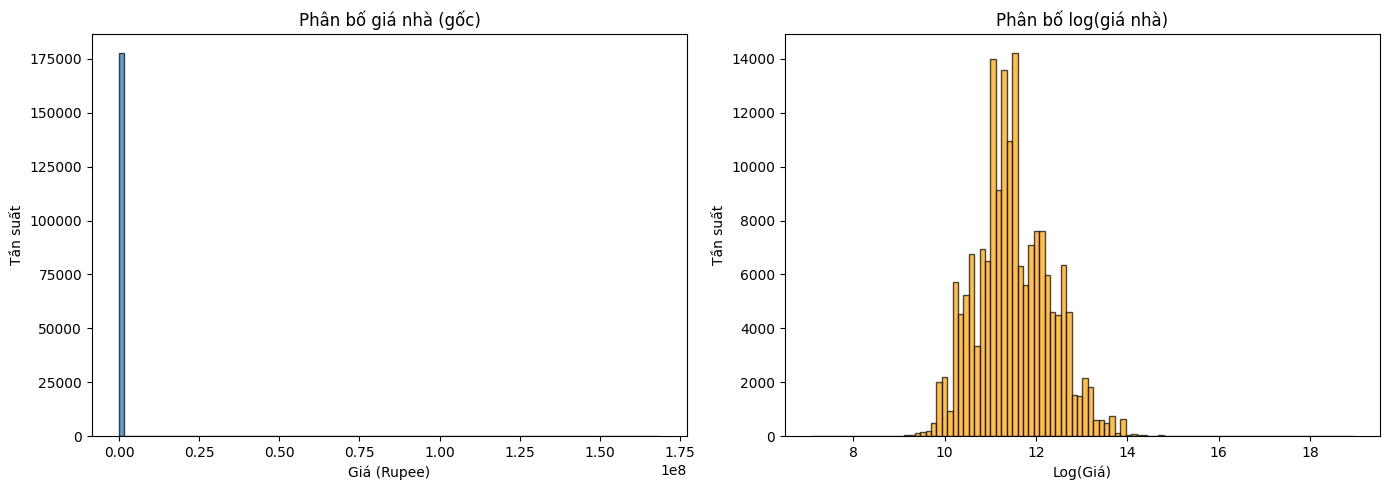

count    1.778470e+05
mean     1.443535e+05
std      4.751599e+05
min      1.204819e+03
25%      5.831325e+04
50%      9.397590e+04
75%      1.746988e+05
max      1.687108e+08
Name: Price_total, dtype: float64


In [23]:
# Phân bố giá nhà (gốc và log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data['Price_total'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_title('Phân bố giá nhà (gốc)')
axes[0].set_xlabel('Giá (Rupee)')
axes[0].set_ylabel('Tần suất')

axes[1].hist(np.log1p(data['Price_total']), bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Phân bố log(giá nhà)')
axes[1].set_xlabel('Log(Giá)')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

print(data['Price_total'].describe())

In [24]:
# Loại bỏ ngoại lệ bằng percentile (1% - 99%)
Q1 = data['Price_total'].quantile(0.01)
Q3 = data['Price_total'].quantile(0.99)
print(f"Giữ lại giá trong khoảng: {Q1:,.0f} - {Q3:,.0f} Rupee")
data = data[(data['Price_total'] >= Q1) & (data['Price_total'] <= Q3)]

Q1_ca = data['Carpet Area'].quantile(0.01)
Q3_ca = data['Carpet Area'].quantile(0.99)
print(f"Giữ lại diện tích trong khoảng: {Q1_ca:,.0f} - {Q3_ca:,.0f} sqft")
data = data[(data['Carpet Area'] >= Q1_ca) & (data['Carpet Area'] <= Q3_ca)]

print(f"\nSố dòng sau khi loại ngoại lệ: {len(data)}")

Giữ lại giá trong khoảng: 19,277 - 843,373 Rupee
Giữ lại diện tích trong khoảng: 375 - 3,440 sqft

Số dòng sau khi loại ngoại lệ: 172018


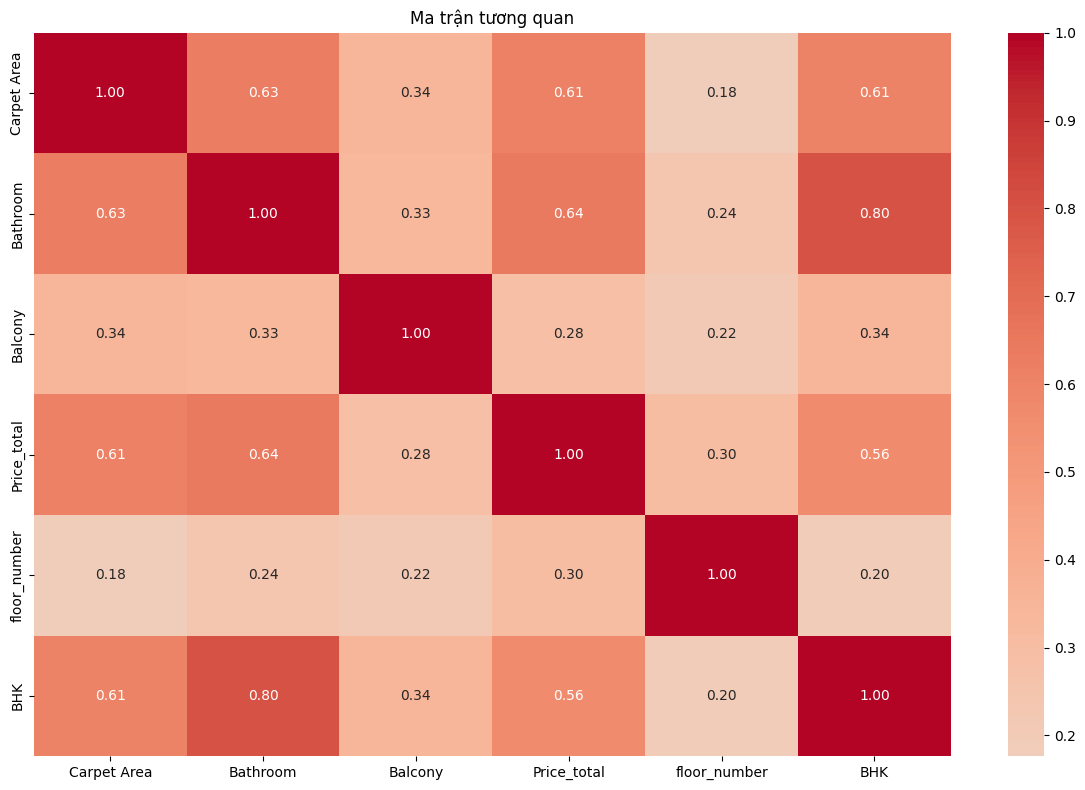

In [25]:
# Ma trận tương quan giữa các biến số
numeric_cols = data.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(12, 8))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0)
ax.set_title('Ma trận tương quan')
plt.tight_layout()
plt.show()

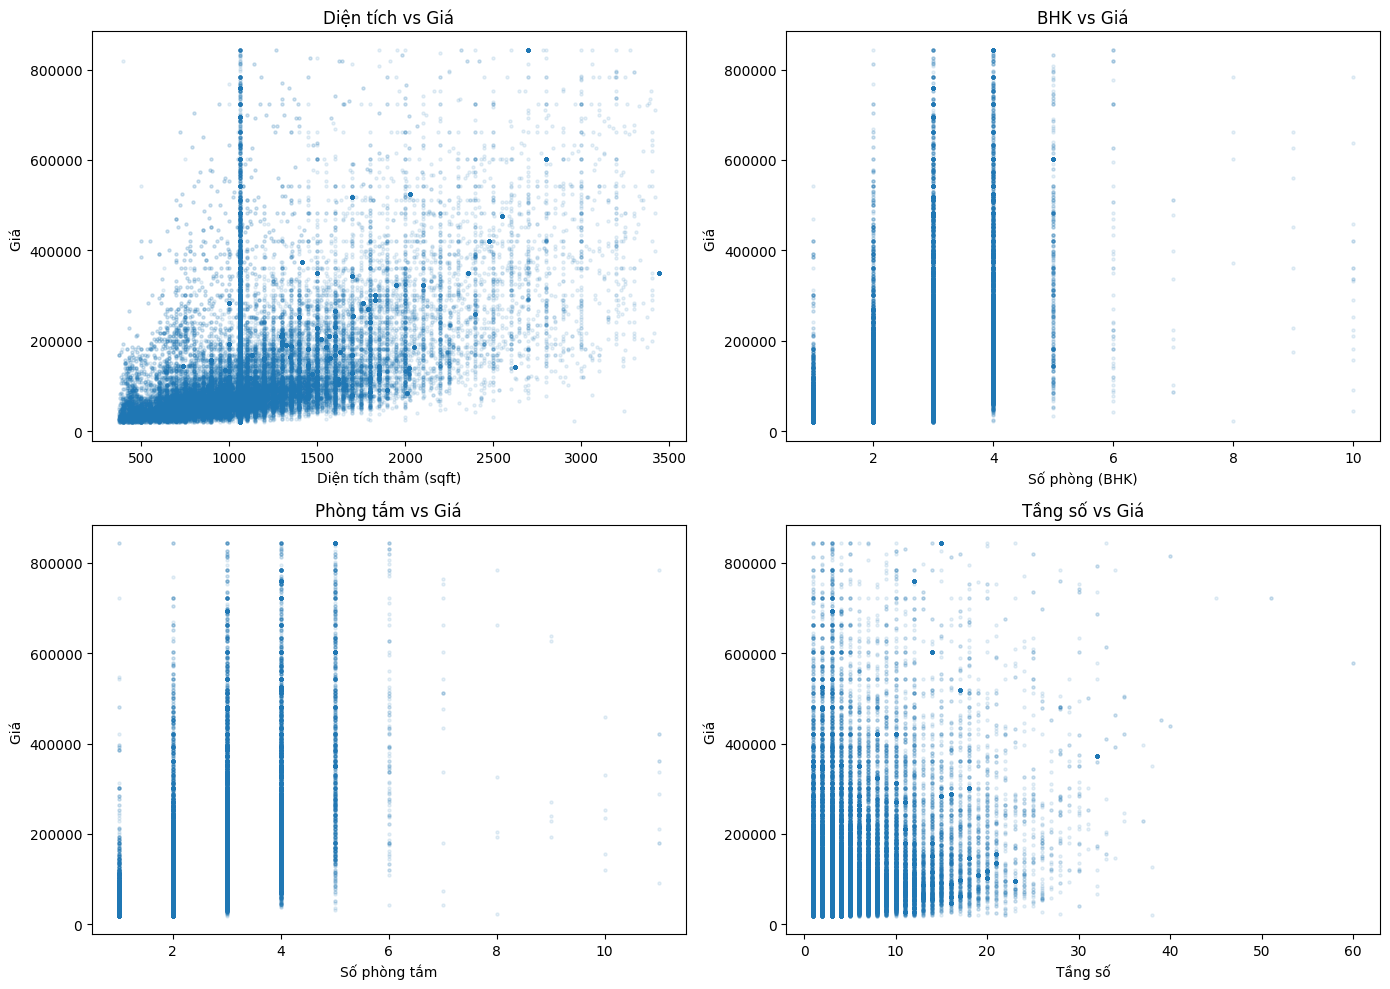

In [26]:
# Biểu đồ phân tán: các biến chính vs giá nhà
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(data['Carpet Area'], data['Price_total'], alpha=0.1, s=5)
axes[0, 0].set_xlabel('Diện tích thảm (sqft)')
axes[0, 0].set_ylabel('Giá ')
axes[0, 0].set_title('Diện tích vs Giá')

axes[0, 1].scatter(data['BHK'], data['Price_total'], alpha=0.1, s=5)
axes[0, 1].set_xlabel('Số phòng (BHK)')
axes[0, 1].set_ylabel('Giá ')
axes[0, 1].set_title('BHK vs Giá')

axes[1, 0].scatter(data['Bathroom'], data['Price_total'], alpha=0.1, s=5)
axes[1, 0].set_xlabel('Số phòng tắm')
axes[1, 0].set_ylabel('Giá ')
axes[1, 0].set_title('Phòng tắm vs Giá')

axes[1, 1].scatter(data['floor_number'], data['Price_total'], alpha=0.1, s=5)
axes[1, 1].set_xlabel('Tầng số')
axes[1, 1].set_ylabel('Giá ')
axes[1, 1].set_title('Tầng số vs Giá')

plt.tight_layout()
plt.show()

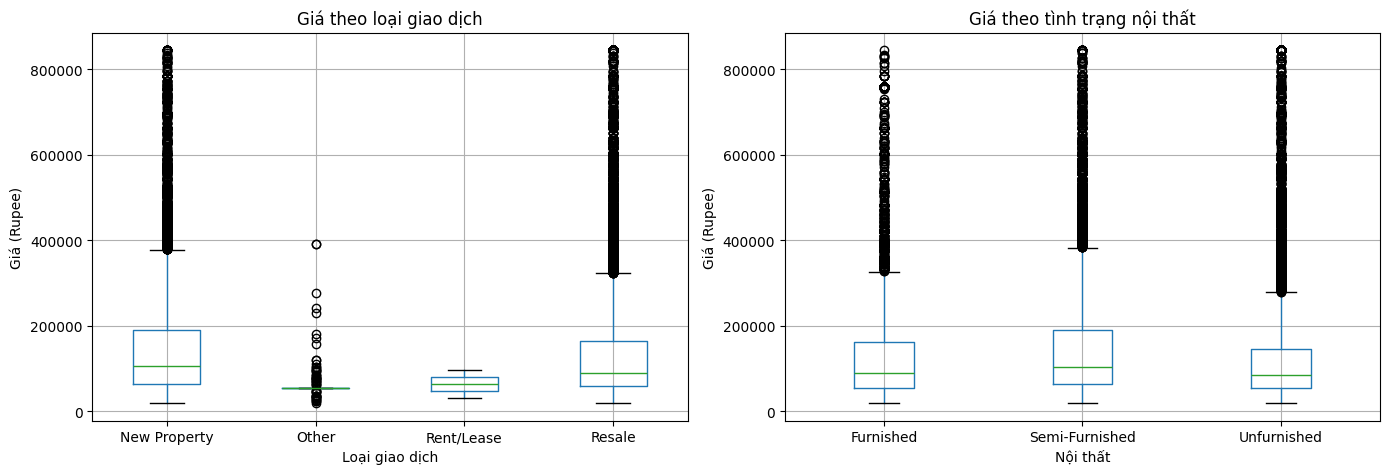

In [27]:
# Boxplot: giá theo loại giao dịch và nội thất
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data.boxplot(column='Price_total', by='Transaction', ax=axes[0])
axes[0].set_title('Giá theo loại giao dịch')
axes[0].set_xlabel('Loại giao dịch')
axes[0].set_ylabel('Giá (Rupee)')

data.boxplot(column='Price_total', by='Furnishing', ax=axes[1])
axes[1].set_title('Giá theo tình trạng nội thất')
axes[1].set_xlabel('Nội thất')
axes[1].set_ylabel('Giá (Rupee)')

plt.suptitle('')
plt.tight_layout()
plt.show()

## Xử lý đặc trưng và mã hóa

In [28]:
# Mã hóa location bằng target encoding (trung bình giá theo thành phố)
location_mean = data.groupby('location')['Price_total'].mean()
data['location_encoded'] = data['location'].map(location_mean)

# Đơn giản hóa overlooking: đếm số tiện ích
data['overlooking_count'] = data['overlooking'].apply(
    lambda x: len(str(x).split(',')) if x != 'Unknown' else 0
)

# Tạo biến nhị phân cho tiện ích phổ biến
for item in ['Garden/Park', 'Main Road', 'Pool', 'Club']:
    col_name = f'overlooking_{item.replace("/", "_").replace(" ", "_")}'
    data[col_name] = data['overlooking'].str.contains(item, case=False, na=False).astype(int)

# One-hot encoding cho các biến phân loại ít danh mục
data = pd.get_dummies(data, columns=['Transaction', 'Furnishing', 'Status',
                                      'Ownership', 'facing'], drop_first=True)

# Xóa cột gốc không cần nữa
data = data.drop(columns=['location', 'overlooking'])

print(f"Shape sau mã hóa: {data.shape}")
data.head()

Shape sau mã hóa: (172018, 29)


,Carpet Area,Bathroom,Balcony,Price_total,floor_number,BHK,location_encoded,overlooking_count,overlooking_Garden_Park,overlooking_Main_Road,...,Ownership_Power Of Attorney,Ownership_Unknown,facing_North,facing_North - East,facing_North - West,facing_South,facing_South - East,facing_South -West,facing_Unknown,facing_West
0,500.0,1.0,2.0,50602.409639,10.0,1.0,118950.673916,0,0,0,...,False,True,False,False,False,False,False,False,True,False
1,473.0,2.0,2.0,118072.289157,3.0,2.0,118950.673916,1,1,0,...,False,False,False,False,False,False,False,False,False,False
2,779.0,2.0,2.0,168674.698795,10.0,2.0,118950.673916,1,1,0,...,False,False,False,False,False,False,False,False,False,False
3,530.0,1.0,1.0,30120.481928,1.0,1.0,118950.673916,0,0,0,...,False,True,False,False,False,False,False,False,True,False
4,635.0,2.0,2.0,192771.084337,20.0,2.0,118950.673916,2,1,1,...,False,False,False,False,False,False,False,False,False,True


In [29]:
# Log-transform biến mục tiêu (giá nhà lệch phải mạnh)
data['log_price'] = np.log1p(data['Price_total'])

data['area_per_bhk'] = data['Carpet Area'] / data['BHK'].clip(lower=1)
data['bath_per_bhk'] = data['Bathroom'] / data['BHK'].clip(lower=1)

print("Các đặc trưng tương tác mới:")
print(data[['area_per_bhk', 'bath_per_bhk']].describe())

Các đặc trưng tương tác mới:
        area_per_bhk   bath_per_bhk
count  172018.000000  172018.000000
mean      459.170868       0.950457
std       151.684083       0.187339
min       100.000000       0.100000
25%       354.666667       1.000000
50%       440.000000       1.000000
75%       532.000000       1.000000
max      3243.000000       4.000000


In [32]:
data[['area_per_bhk', 'bath_per_bhk']].describe()

,area_per_bhk,bath_per_bhk
count,172018.000000,172018.000000
mean,459.170868,0.950457
std,151.684083,0.187339
min,100.000000,0.100000
25%,354.666667,1.000000
50%,440.000000,1.000000
75%,532.000000,1.000000
max,3243.000000,4.000000


## Xây dựng mô hình hồi quy tuyến tính

In [33]:
# Chuẩn bị dữ liệu cho mô hình
target = 'log_price'

drop_cols = ['Price_total', 'log_price']
feature_cols = [c for c in data.columns if c not in drop_cols]

X = data[feature_cols].copy()
y = data[target].copy()

# Xử lý inf/nan còn sót
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print(f"Số đặc trưng: {X.shape[1]}")
print(f"Số mẫu: {X.shape[0]}")
print(f"\nDanh sách đặc trưng ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  {i+1}. {col}")

# Chia tập train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTập train: {X_train.shape[0]} mẫu")
print(f"Tập test: {X_test.shape[0]} mẫu")

Số đặc trưng: 30
Số mẫu: 172018

Danh sách đặc trưng (30):
  1. Carpet Area
  2. Bathroom
  3. Balcony
  4. floor_number
  5. BHK
  6. location_encoded
  7. overlooking_count
  8. overlooking_Garden_Park
  9. overlooking_Main_Road
  10. overlooking_Pool
  11. overlooking_Club
  12. Transaction_Other
  13. Transaction_Rent/Lease
  14. Transaction_Resale
  15. Furnishing_Semi-Furnished
  16. Furnishing_Unfurnished
  17. Ownership_Freehold
  18. Ownership_Leasehold
  19. Ownership_Power Of Attorney
  20. Ownership_Unknown
  21. facing_North
  22. facing_North - East
  23. facing_North - West
  24. facing_South
  25. facing_South - East
  26. facing_South -West
  27. facing_Unknown
  28. facing_West
  29. area_per_bhk
  30. bath_per_bhk

Tập train: 137614 mẫu
Tập test: 34404 mẫu


In [34]:
# Chuẩn hóa đặc trưng
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Huấn luyện mô hình hồi quy tuyến tính
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Hoàn thành huấn luyện mô hình Linear Regression!")

Hoàn thành huấn luyện mô hình Linear Regression!


In [40]:
# Dự đoán trên tập test
y_pred_log = model.predict(X_test_scaled)

# Chuyển về giá gốc (undo log transform)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# Loại bỏ dự đoán âm
y_pred = np.clip(y_pred, 0, None)

# Tính các chỉ số đánh giá
r2 = r2_score(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

# MAPE (loại bỏ giá trị 0 để tránh chia cho 0)
mask = y_actual > 0
mape = np.mean(np.abs((y_actual[mask] - y_pred[mask]) / y_actual[mask])) * 100

# R² trên log scale
r2_log = r2_score(y_test, y_pred_log)

print("=" * 55)
print("  KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH HỒI QUY TUYẾN TÍNH")
print("=" * 55)
print(f"  R² Score (log scale):          {r2_log:.4f}")
print(f"  R² Score (giá gốc):            {r2:.4f}")
print(f"  MAE (Mean Absolute Error):      {mae:,.0f} Rupee")
print(f"  RMSE (Root Mean Squared Error): {rmse:,.0f} Rupee")
print(f"  MAPE (Mean Abs % Error):        {mape:.2f}%")
print("=" * 55)

  KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH HỒI QUY TUYẾN TÍNH
  R² Score (log scale):          0.6401
  R² Score (giá gốc):            0.5163
  MAE (Mean Absolute Error):      46,066 Rupee
  RMSE (Root Mean Squared Error): 82,903 Rupee
  MAPE (Mean Abs % Error):        38.32%


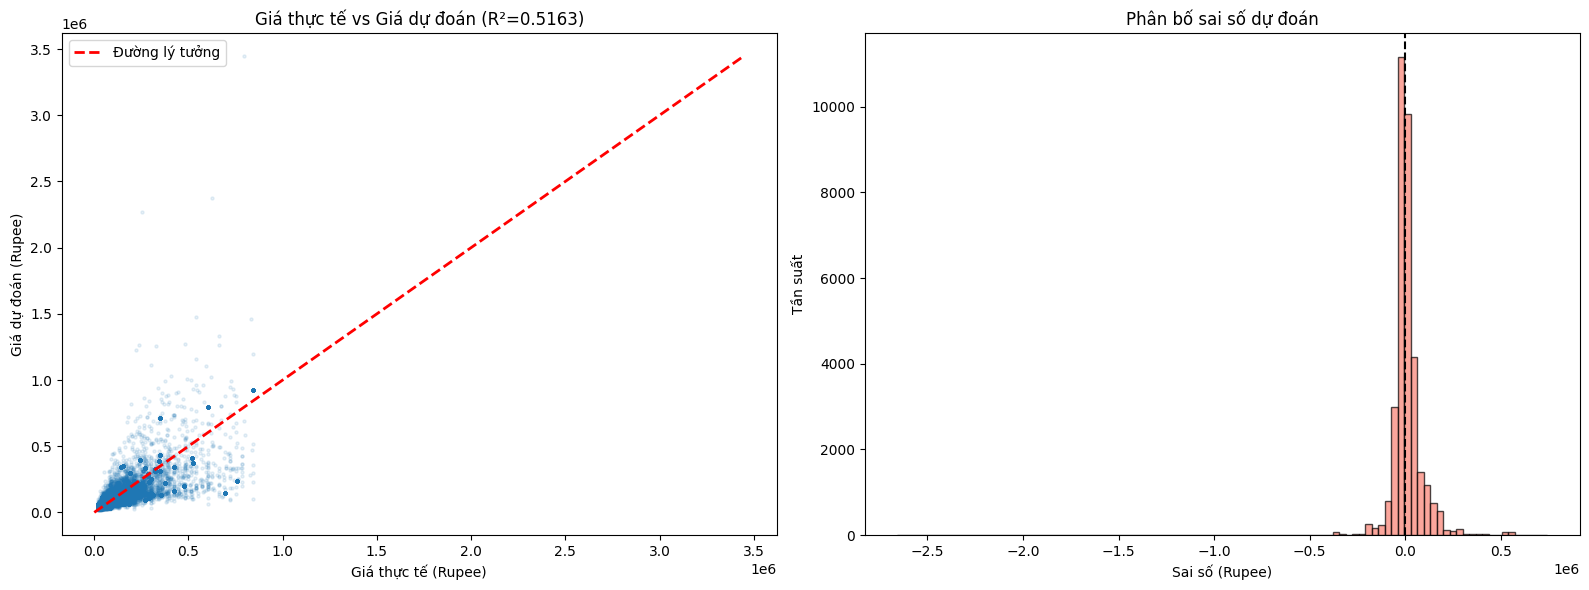

In [41]:
# Biểu đồ: Giá thực tế vs Giá dự đoán + Phân bố sai số
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Thực tế vs Dự đoán
axes[0].scatter(y_actual, y_pred, alpha=0.1, s=5)
max_val = max(y_actual.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Đường lý tưởng')
axes[0].set_xlabel('Giá thực tế (Rupee)')
axes[0].set_ylabel('Giá dự đoán (Rupee)')
axes[0].set_title(f'Giá thực tế vs Giá dự đoán (R²={r2:.4f})')
axes[0].legend()

# Phân bố sai số
residuals = y_actual - y_pred
axes[1].hist(residuals, bins=100, edgecolor='black', alpha=0.7, color='salmon')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_xlabel('Sai số (Rupee)')
axes[1].set_ylabel('Tần suất')
axes[1].set_title('Phân bố sai số dự đoán')

plt.tight_layout()
plt.show()

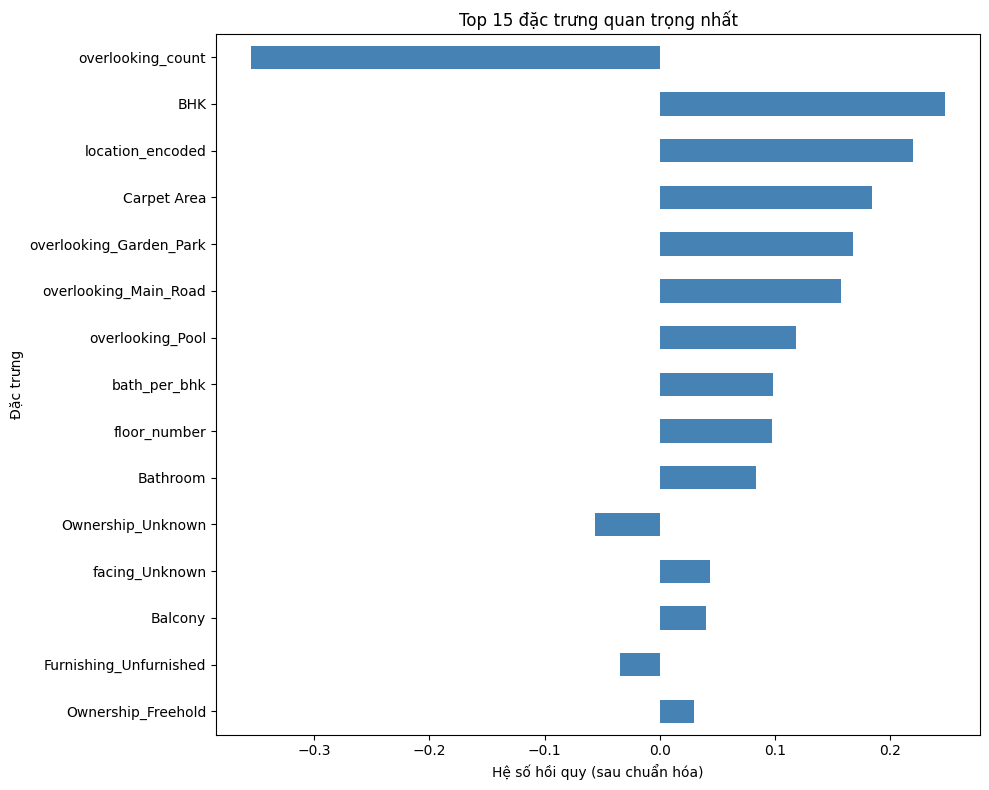

In [42]:
# Top 15 đặc trưng quan trọng nhất (theo hệ số hồi quy)
feature_importance = pd.DataFrame({
    'Đặc trưng': feature_cols,
    'Hệ số': model.coef_
})
feature_importance['Abs_hệ_số'] = feature_importance['Hệ số'].abs()
feature_importance = feature_importance.sort_values('Abs_hệ_số', ascending=True)

top_n = min(15, len(feature_importance))
fig, ax = plt.subplots(figsize=(10, 8))
feature_importance.tail(top_n).plot.barh(x='Đặc trưng', y='Hệ số', ax=ax, color='steelblue', legend=False)
ax.set_title(f'Top {top_n} đặc trưng quan trọng nhất')
ax.set_xlabel('Hệ số hồi quy (sau chuẩn hóa)')
plt.tight_layout()
plt.show()

R² trên tập train (log): 0.6431
R² trên tập test (log):  0.6401
Chênh lệch:              0.0030

Mô hình khái quát hóa tốt.


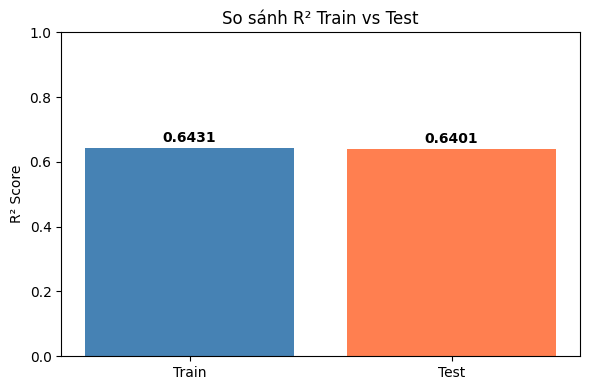

In [43]:
# Kiểm tra overfitting: so sánh R² train vs test
y_train_pred_log = model.predict(X_train_scaled)
r2_train = r2_score(y_train, y_train_pred_log)
r2_test = r2_score(y_test, y_pred_log)

print(f"R² trên tập train (log): {r2_train:.4f}")
print(f"R² trên tập test (log):  {r2_test:.4f}")
print(f"Chênh lệch:              {r2_train - r2_test:.4f}")

if r2_train - r2_test > 0.05:
    print("\nMô hình có dấu hiệu overfitting!")
else:
    print("\nMô hình khái quát hóa tốt.")

# Biểu đồ so sánh
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Train', 'Test'], [r2_train, r2_test], color=['steelblue', 'coral'])
ax.set_ylabel('R² Score')
ax.set_title('So sánh R² Train vs Test')
ax.set_ylim(0, 1)
for bar, val in zip(bars, [r2_train, r2_test]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## So sánh với các thuật toán ML khác

In [44]:
# Huấn luyện Random Forest
print("Đang huấn luyện Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

rf_pred_log = rf_model.predict(X_test_scaled)
rf_pred = np.clip(np.expm1(rf_pred_log), 0, None)

print("Đang huấn luyện Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
)
gb_model.fit(X_train_scaled, y_train)

gb_pred_log = gb_model.predict(X_test_scaled)
gb_pred = np.clip(np.expm1(gb_pred_log), 0, None)

print("Hoàn thành huấn luyện cả 2 mô hình!")

Đang huấn luyện Random Forest...
Đang huấn luyện Gradient Boosting...
Hoàn thành huấn luyện cả 2 mô hình!


In [45]:
# Bảng so sánh metrics 3 mô hình
def calc_metrics(y_true, y_pred, y_true_log, y_pred_log):
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {
        'R² (log)': r2_score(y_true_log, y_pred_log),
        'R² (giá gốc)': r2_score(y_true, y_pred),
        'MAE (Rupee)': mean_absolute_error(y_true, y_pred),
        'RMSE (Rupee)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': mape
    }

results = {
    'Linear Regression': calc_metrics(y_actual, y_pred, y_test, y_pred_log),
    'Random Forest': calc_metrics(y_actual, rf_pred, y_test, rf_pred_log),
    'Gradient Boosting': calc_metrics(y_actual, gb_pred, y_test, gb_pred_log),
}

comparison = pd.DataFrame(results).T
comparison['MAE (Rupee)'] = comparison['MAE (Rupee)'].apply(lambda x: f"{x:,.0f}")
comparison['RMSE (Rupee)'] = comparison['RMSE (Rupee)'].apply(lambda x: f"{x:,.0f}")
comparison['MAPE (%)'] = comparison['MAPE (%)'].apply(lambda x: f"{x:.2f}")
comparison['R² (log)'] = comparison['R² (log)'].apply(lambda x: f"{x:.4f}")
comparison['R² (giá gốc)'] = comparison['R² (giá gốc)'].apply(lambda x: f"{x:.4f}")

print("=" * 70)
print("         BẢNG SO SÁNH 3 MÔ HÌNH")
print("=" * 70)
comparison

         BẢNG SO SÁNH 3 MÔ HÌNH


,R² (log),R² (giá gốc),MAE (Rupee),RMSE (Rupee),MAPE (%)
Linear Regression,0.6401,0.5163,"46,066","82,903",38.32
Random Forest,0.9112,0.9108,"13,203","35,608",12.09
Gradient Boosting,0.8880,0.8727,"19,645","42,528",16.78


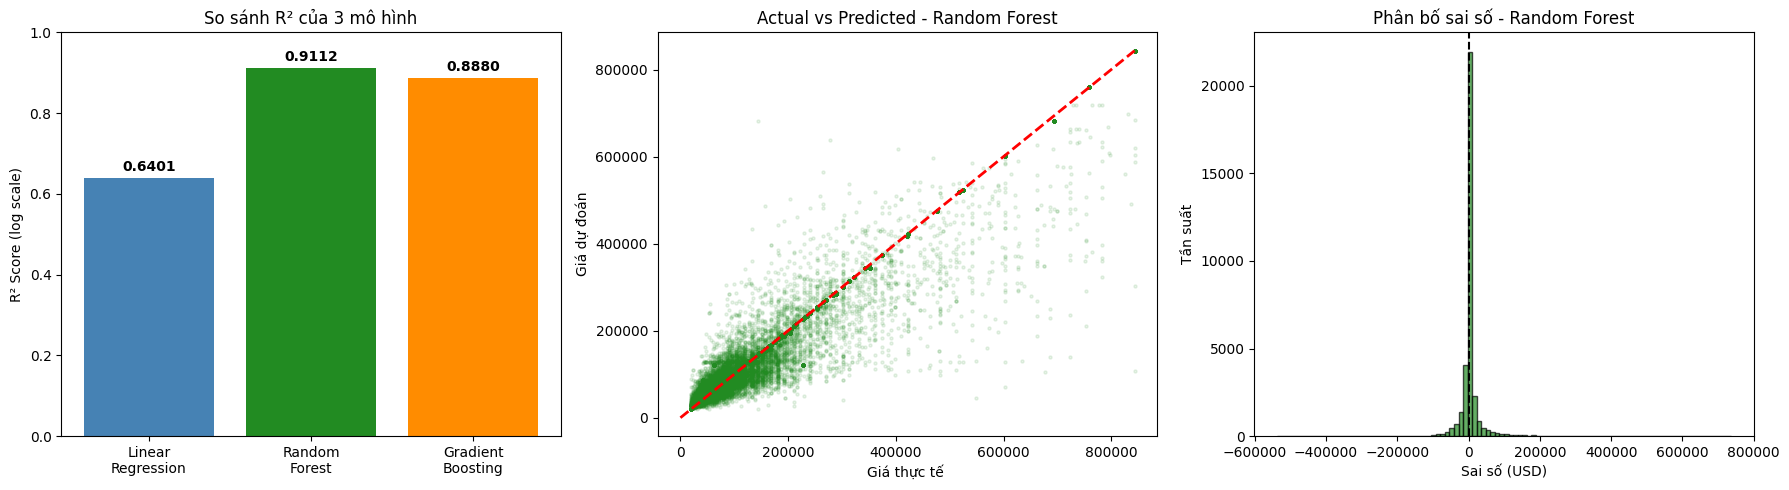


Mô hình tốt nhất: Random Forest (R² log = 0.9112)


In [46]:
# Biểu đồ so sánh R² (log scale) của 3 mô hình
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart so sánh R²
models = ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting']
r2_logs = [r2_score(y_test, y_pred_log),
           r2_score(y_test, rf_pred_log),
           r2_score(y_test, gb_pred_log)]
colors = ['steelblue', 'forestgreen', 'darkorange']

bars = axes[0].bar(models, r2_logs, color=colors)
axes[0].set_ylabel('R² Score (log scale)')
axes[0].set_title('So sánh R² của 3 mô hình')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, r2_logs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Tìm mô hình tốt nhất
best_idx = np.argmax(r2_logs)
best_preds = [y_pred, rf_pred, gb_pred]
best_preds_log = [y_pred_log, rf_pred_log, gb_pred_log]
best_name = ['Linear Regression', 'Random Forest', 'Gradient Boosting'][best_idx]

# Scatter: Actual vs Predicted cho mô hình tốt nhất
axes[1].scatter(y_actual, best_preds[best_idx], alpha=0.1, s=5, color=colors[best_idx])
max_val = max(y_actual.max(), best_preds[best_idx].max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=2)
axes[1].set_xlabel('Giá thực tế ')
axes[1].set_ylabel('Giá dự đoán')
axes[1].set_title(f'Actual vs Predicted - {best_name}')

# Residual plot cho mô hình tốt nhất
best_residuals = y_actual - best_preds[best_idx]
axes[2].hist(best_residuals, bins=100, edgecolor='black', alpha=0.7, color=colors[best_idx])
axes[2].axvline(x=0, color='black', linestyle='--')
axes[2].set_xlabel('Sai số (USD)')
axes[2].set_ylabel('Tần suất')
axes[2].set_title(f'Phân bố sai số - {best_name}')

plt.tight_layout()
plt.show()

print(f"\nMô hình tốt nhất: {best_name} (R² log = {r2_logs[best_idx]:.4f})")

## Nhận xét

- **Linear Regression**: Mô hình đơn giản, dễ diễn giải nhưng bị giới hạn bởi giả định quan hệ tuyến tính. R² trên giá gốc âm do log-transform khuếch đại sai số khi chuyển về giá thực.
- **Random Forest**: Bắt được quan hệ phi tuyến và tương tác giữa các đặc trưng mà không cần feature engineering thủ công. Thường cho kết quả tốt hơn đáng kể.
- **Gradient Boosting**: Học tuần tự từ sai số của cây trước, thường đạt hiệu suất cao nhất trên dữ liệu dạng bảng.

Giá nhà phụ thuộc mạnh vào **location** (thành phố), **diện tích**, và **số phòng** — các mối quan hệ này thường phi tuyến, giải thích tại sao các mô hình tree-based vượt trội hơn Linear Regression.